In [1]:
from pathlib import Path
from PIL import Image
import pandas as pd
import matplotlib.pyplot as plt
import random

In [2]:
DATASET_ROOT = Path("data/raw/Data")

TRAIN_DIR = DATASET_ROOT / "train"
VALID_DIR = DATASET_ROOT / "valid"
TEST_DIR = DATASET_ROOT / "test"

IMAGE_EXTENSIONS = (".png", ".jpg", ".jpeg")

print("Train exists:", TRAIN_DIR.exists())
print("Valid exists:", VALID_DIR.exists())
print("Test exists:", TEST_DIR.exists())

Train exists: True
Valid exists: True
Test exists: True


In [3]:
def get_image_paths(folder: Path) -> list[Path]:
    return sorted(
        path
        for path in folder.iterdir()
        if path.is_file() and path.suffix.lower() in IMAGE_EXTENSIONS
    )


def clean_class_name(folder_name: str) -> str:
    if "adenocarcinoma" in folder_name:
        return "adenocarcinoma"
    if "large.cell.carcinoma" in folder_name:
        return "large.cell.carcinoma"
    if "squamous.cell.carcinoma" in folder_name:
        return "squamous.cell.carcinoma"
    if "normal" in folder_name:
        return "normal"

    return folder_name

In [4]:
dataset_splits = {
    "train": TRAIN_DIR,
    "valid": VALID_DIR,
    "test": TEST_DIR,
}

class_distribution_records = []

for split_name, split_path in dataset_splits.items():
    for class_path in split_path.iterdir():
        if class_path.is_dir():
            image_paths = get_image_paths(class_path)

            class_distribution_records.append({
                "split": split_name,
                "class_name": clean_class_name(class_path.name),
                "original_folder": class_path.name,
                "number_of_images": len(image_paths),
            })

class_distribution = pd.DataFrame(class_distribution_records)

class_distribution

,split,class_name,original_folder,number_of_images
0,train,adenocarcinoma,adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib,195
1,train,squamous.cell.carcinoma,squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa,155
2,train,normal,normal,148
3,train,large.cell.carcinoma,large.cell.carcinoma_left.hilum_T2_N2_M0_IIIa,115
4,valid,adenocarcinoma,adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib,23
5,valid,squamous.cell.carcinoma,squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa,15
6,valid,normal,normal,13
7,valid,large.cell.carcinoma,large.cell.carcinoma_left.hilum_T2_N2_M0_IIIa,21
8,test,normal,normal,54
9,test,squamous.cell.carcinoma,squamous.cell.carcinoma,90


In [5]:
class_distribution_pivot = class_distribution.pivot_table(
    index="class_name",
    columns="split",
    values="number_of_images",
    aggfunc="sum",
    fill_value=0,
).astype(int)

class_distribution_pivot

split,test,train,valid
class_name,,,
adenocarcinoma,120,195,23
large.cell.carcinoma,51,115,21
normal,54,148,13
squamous.cell.carcinoma,90,155,15


In [6]:
split_distribution = (
    class_distribution
    .groupby("split", as_index=False)["number_of_images"]
    .sum()
)

total_images = split_distribution["number_of_images"].sum()

split_distribution["percentage"] = (
    split_distribution["number_of_images"] / total_images * 100
).round(2)

split_distribution

,split,number_of_images,percentage
0,test,315,31.5
1,train,613,61.3
2,valid,72,7.2


In [7]:
image_metadata_records = []

for split_name, split_path in dataset_splits.items():
    for class_path in split_path.iterdir():
        if class_path.is_dir():
            image_paths = get_image_paths(class_path)

            for image_path in image_paths:
                try:
                    with Image.open(image_path) as image:
                        width, height = image.size

                        image_metadata_records.append({
                            "split": split_name,
                            "class_name": clean_class_name(class_path.name),
                            "original_folder": class_path.name,
                            "image_path": str(image_path),
                            "width": width,
                            "height": height,
                            "mode": image.mode,
                            "extension": image_path.suffix.lower(),
                        })

                except Exception as error:
                    print(f"Could not read image: {image_path}")
                    print(error)

image_metadata = pd.DataFrame(image_metadata_records)

image_metadata.head()

,split,class_name,original_folder,image_path,width,height,mode,extension
0,train,adenocarcinoma,adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib,data/raw/Data/train/adenocarcinoma_left.lower....,409,264,RGBA,.png
1,train,adenocarcinoma,adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib,data/raw/Data/train/adenocarcinoma_left.lower....,397,243,RGBA,.png
2,train,adenocarcinoma,adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib,data/raw/Data/train/adenocarcinoma_left.lower....,392,244,RGBA,.png
3,train,adenocarcinoma,adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib,data/raw/Data/train/adenocarcinoma_left.lower....,377,220,RGBA,.png
4,train,adenocarcinoma,adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib,data/raw/Data/train/adenocarcinoma_left.lower....,373,272,RGBA,.png


In [8]:
image_metadata[["width", "height"]].describe()

,width,height
count,1000.000000,1000.000000
mean,446.997000,317.779000
std,127.228936,101.853553
min,168.000000,110.000000
25%,385.000000,254.000000
50%,419.000000,296.000000
75%,450.000000,341.000000
max,1200.000000,874.000000


In [9]:
image_metadata["mode"].value_counts()

mode
RGBA    923
RGB      74
L         3
Name: count, dtype: int64

In [10]:
image_metadata["extension"].value_counts()

extension
.png    988
.jpg     12
Name: count, dtype: int64

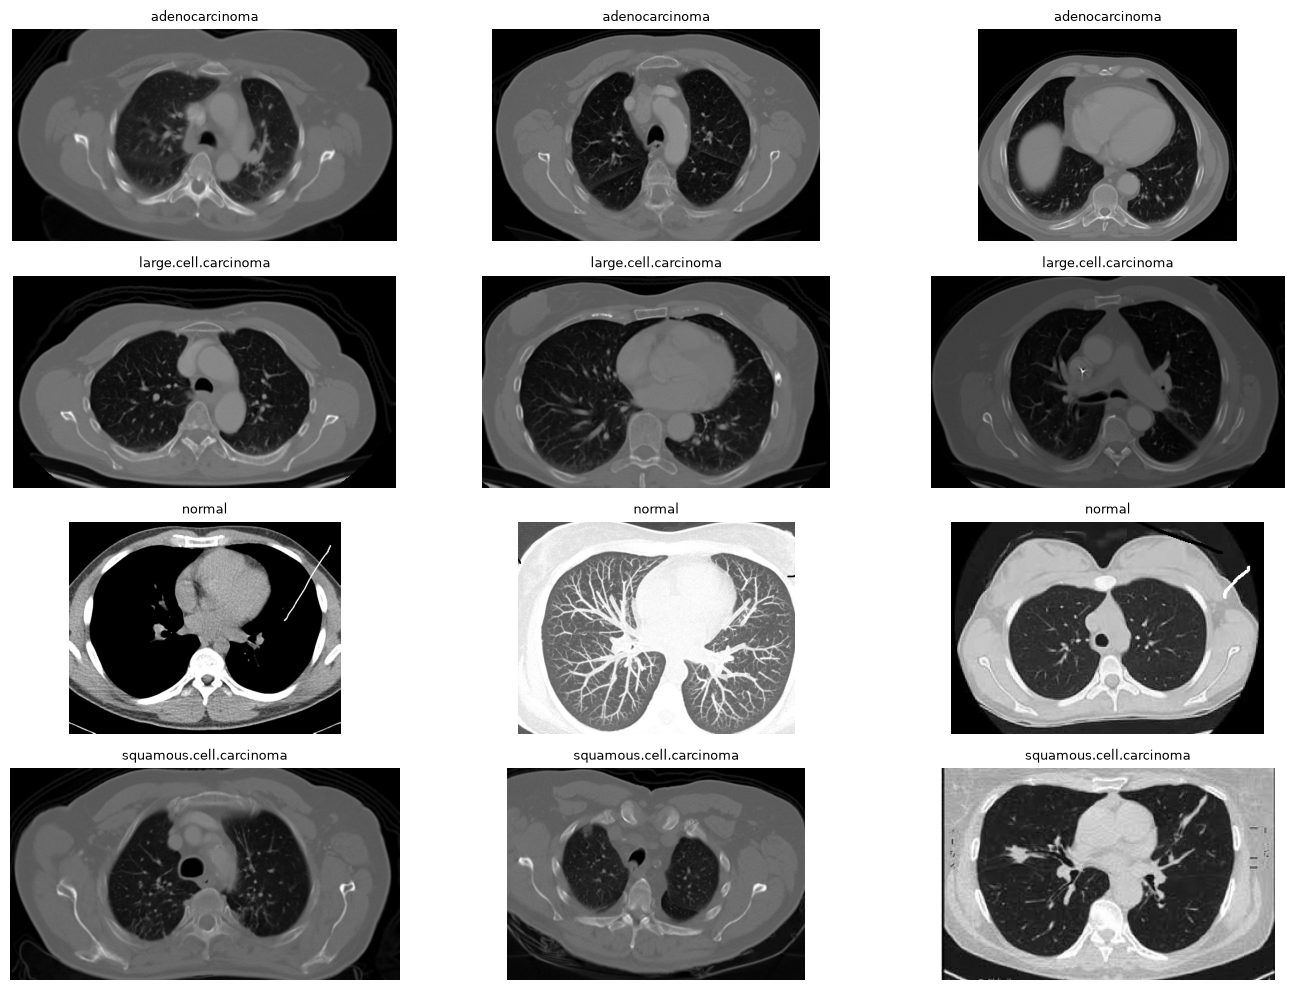

In [11]:
train_class_paths = sorted(
    class_path for class_path in TRAIN_DIR.iterdir()
    if class_path.is_dir()
)

number_of_samples_per_class = 3

plt.figure(figsize=(14, 10))
plot_index = 1

for class_path in train_class_paths:
    image_paths = get_image_paths(class_path)

    sample_image_paths = random.sample(
        image_paths,
        min(number_of_samples_per_class, len(image_paths))
    )

    for image_path in sample_image_paths:
        image = Image.open(image_path).convert("RGB")

        plt.subplot(
            len(train_class_paths),
            number_of_samples_per_class,
            plot_index,
        )

        plt.imshow(image)
        plt.title(clean_class_name(class_path.name), fontsize=9)
        plt.axis("off")

        plot_index += 1

plt.tight_layout()
plt.show()